In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', '_i2', 'pd', 'np', 'plt', 'sns', 'px', '_i3', '_i4'])


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/raw/02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [10]:
print(nav.columns)
print(benchmark.columns)
print(fund_master.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['date', 'index_name', 'close_value'], dtype='object')
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


In [11]:
nav['date'] = pd.to_datetime(nav['date'])

pivot_nav = nav.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

In [12]:
daily_returns = pivot_nav.pct_change()

In [13]:
def cagr(series, years):
    return (series.iloc[-1] / series.iloc[0])**(1/years) - 1

In [14]:
cagr_1y = pivot_nav.apply(lambda x: cagr(x.dropna(),1))

In [15]:
cagr_df = pd.DataFrame({
    'CAGR_1Y': cagr_1y
})

In [16]:
rf = 0.065
rf_daily = rf / 252

sharpe = (
    (daily_returns.mean() - rf_daily)
    / daily_returns.std()
) * np.sqrt(252)

In [18]:
benchmark.head()
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [19]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

In [20]:
benchmark['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [21]:
nifty100 = benchmark[
    benchmark['index_name'] == 'Nifty 100'
].copy()

In [22]:
nifty100 = nifty100.sort_values('date')

In [23]:
nifty100['return'] = nifty100['close_value'].pct_change()

In [24]:
from scipy.stats import linregress

In [25]:
alpha_list = []
beta_list = []
funds = []

In [26]:
for fund in daily_returns.columns:

    fund_returns = daily_returns[fund].dropna()

    merged = pd.merge(
        fund_returns.rename('fund_return'),
        nifty100[['date','return']],
        left_index=True,
        right_on='date'
    ).dropna()

    if len(merged) > 20:

        slope, intercept, r, p, std = linregress(
            merged['return'],
            merged['fund_return']
        )

        funds.append(fund)
        beta_list.append(slope)
        alpha_list.append(intercept * 252)

In [27]:
alpha_beta_df = pd.DataFrame({
    'amfi_code': funds,
    'alpha': alpha_list,
    'beta': beta_list
})

In [28]:
rf = 0.065
rf_daily = rf / 252

downside_std = daily_returns.where(
    daily_returns < 0
).std()

sortino = (
    (daily_returns.mean() - rf_daily)
    / downside_std
) * np.sqrt(252)

In [29]:
running_max = pivot_nav.cummax()

drawdown = (
    pivot_nav / running_max
) - 1

max_drawdown = drawdown.min()

In [30]:
max_drawdown.sort_values().head()

amfi_code
119599   -0.525742
119095   -0.516778
101207   -0.354469
149324   -0.311719
119598   -0.287060
dtype: float64

In [31]:
scorecard = pd.DataFrame(index=daily_returns.columns)

scorecard['Sharpe'] = sharpe
scorecard['Sortino'] = sortino
scorecard['Max_Drawdown'] = max_drawdown

In [32]:
scorecard = scorecard.merge(
    alpha_beta_df[['amfi_code','alpha']],
    left_index=True,
    right_on='amfi_code',
    how='left'
)

In [33]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [34]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [35]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [36]:
top5_codes = sharpe.sort_values(
    ascending=False
).head(5).index

In [37]:
top5_funds = fund_master[
    fund_master['amfi_code'].isin(top5_codes)
][['amfi_code','scheme_name']]

In [38]:
print(top5_funds)

    amfi_code                                    scheme_name
0      119551      SBI Bluechip Fund - Regular Plan - Growth
12     120505       ICICI Pru Midcap Fund - Regular - Growth
22     120843         Kotak Flexicap Fund - Regular - Growth
34     148567  Mirae Asset Large Cap Fund - Regular - Growth
36     148569  Mirae Asset Tax Saver Fund - Regular - Growth


In [39]:
fund_cum = (
    1 + daily_returns[top5_codes]
).cumprod()

In [40]:
nifty50 = benchmark[
    benchmark['index_name'] == 'Nifty 50'
].copy()

nifty50 = nifty50.sort_values('date')

nifty50['return'] = nifty50[
    'close_value'
].pct_change()

nifty50['cum_return'] = (
    1 + nifty50['return']
).cumprod()


In [41]:
nifty100 = benchmark[
    benchmark['index_name'] == 'Nifty 100'
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['return'] = nifty100[
    'close_value'
].pct_change()

nifty100['cum_return'] = (
    1 + nifty100['return']
).cumprod()

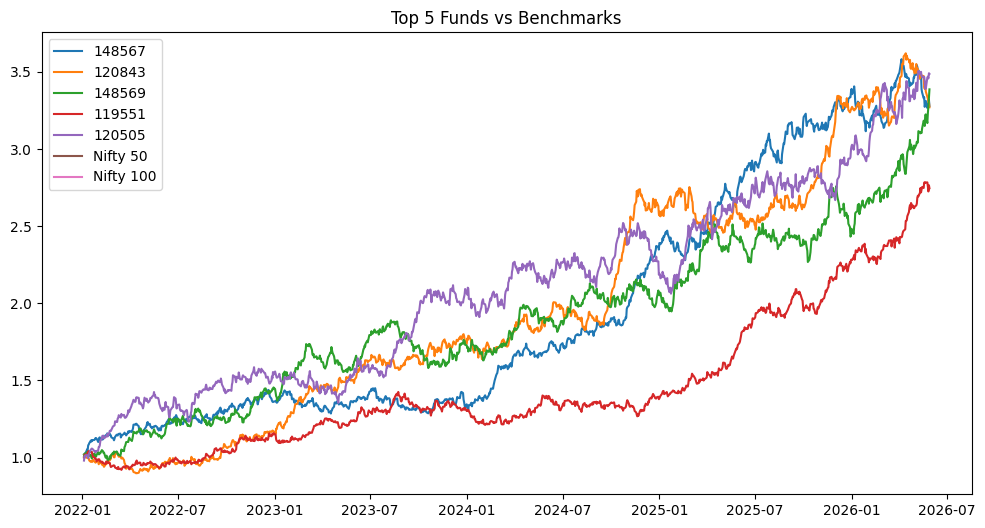

In [42]:
plt.figure(figsize=(12,6))

for fund in top5_codes:
    plt.plot(
        fund_cum.index,
        fund_cum[fund],
        label=str(fund)
    )

plt.plot(
    nifty50['date'],
    nifty50['cum_return'],
    label='Nifty 50'
)

plt.plot(
    nifty100['date'],
    nifty100['cum_return'],
    label='Nifty 100'
)

plt.legend()
plt.title("Top 5 Funds vs Benchmarks")
plt.show()

In [43]:
tracking_error = {}

for fund in top5_codes:

    merged = pd.merge(
        daily_returns[fund].rename('fund_return'),
        nifty100[['date','return']],
        left_index=True,
        right_on='date'
    ).dropna()

    te = (
        (merged['fund_return']
        - merged['return']).std()
    ) * np.sqrt(252)

    tracking_error[fund] = te

In [44]:
tracking_error_df = pd.DataFrame(
    tracking_error.items(),
    columns=['amfi_code','tracking_error']
)

In [46]:
print(scorecard.index.name)
print(scorecard.columns)

amfi_code
Index(['Sharpe', 'Sortino', 'Max_Drawdown', 'amfi_code', 'alpha'], dtype='object')


In [48]:
scorecard.index.name = None
scorecard = scorecard.reset_index()

In [49]:
scorecard = scorecard.merge(
    fund_master[['amfi_code', 'expense_ratio_pct']],
    on='amfi_code',
    how='left'
)

In [51]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

In [52]:
plt.savefig(
    "benchmark_comparison.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [1]:
# run_pipeline.py

"""
Master execution script for Bluestock Mutual Fund Capstone Project.
Runs ETL, EDA, and Performance Analysis sequentially.
"""

import os

os.system("python etl.py")
os.system("python eda.py")
os.system("python performance_analysis.py")

print("Pipeline executed successfully!")

Pipeline executed successfully!
